<a href="https://colab.research.google.com/github/daval12/mitlab3/blob/main/Copy_of_fine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip uninstall -y datasets huggingface_hub transformers tokenizers fsspec

Found existing installation: datasets 3.6.0
Uninstalling datasets-3.6.0:
  Successfully uninstalled datasets-3.6.0
Found existing installation: huggingface_hub 0.36.2
Uninstalling huggingface_hub-0.36.2:
  Successfully uninstalled huggingface_hub-0.36.2
Found existing installation: transformers 4.53.3
Uninstalling transformers-4.53.3:
  Successfully uninstalled transformers-4.53.3
Found existing installation: tokenizers 0.21.4
Uninstalling tokenizers-0.21.4:
  Successfully uninstalled tokenizers-0.21.4
Found existing installation: fsspec 2025.3.0
Uninstalling fsspec-2025.3.0:
  Successfully uninstalled fsspec-2025.3.0


In [ ]:
!pip install -q \
transformers==4.53.3 \
datasets==3.6.0 \
huggingface_hub==0.33.5 \
tokenizers==0.21.4 \
accelerate==1.8.1 \
peft==0.16.0 \
trl==0.19.1 \
bitsandbytes \
fsspec==2025.3.0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.7.2 requires huggingface_hub>=0.34.0, but you have huggingface-hub 0.33.5 which is incompatible.
unsloth-zoo 2026.7.2 requires peft!=0.11.0,>=0.18.0; sys_platform != "darwin" or platform_machine != "arm64", but you have peft 0.16.0 which is incompatible.
unsloth 2026.7.2 requires huggingface_hub>=0.34.0, but you have huggingface-hub 0.33.5 which is incompatible.
unsloth 2026.7.2 requires peft!=0.11.0,>=0.18.0, but you have peft 0.16.0 which is incompatible.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.33.5 which is incompatible.
diffusers 0.38.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.33.5 which is incompatible.


In [ ]:
import datasets
import transformers
import huggingface_hub

print(datasets.__version__)
print(transformers.__version__)
print(huggingface_hub.__version__)

3.6.0
4.53.3
0.36.2


In [ ]:
from datasets import load_dataset

dataset = load_dataset("cnn_dailymail", "3.0.0")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})


In [ ]:
sample  = dataset['train'][0]
print(type(sample['article']))
print(sample['article'])

<class 'str'>
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office chart. 

In [ ]:
def preprocess(example):
    example["article"] = " ".join(example["article"].split())
    example["highlights"] = " ".join(example["highlights"].split())
    return example

processed_dataset = dataset.map(preprocess)

In [ ]:
removed_dataset = processed_dataset.remove_columns(["id"])

In [ ]:
print(removed_dataset["train"].column_names)

['article', 'highlights']


In [ ]:
print("Training samples:", len(removed_dataset["train"]))
print("Validation samples:", len(removed_dataset["validation"]))
print("Test samples:", len(removed_dataset["test"]))

Training samples: 287113
Validation samples: 13368
Test samples: 11490


In [ ]:
train = removed_dataset["train"]

empty_articles = sum(1 for article in train["article"] if article.strip() == "")
empty_higlights  = sum(1 for summary in train["highlights"] if summary.strip() == "")

print("Empty Articles:", empty_articles)
print("Empty Summaries:", empty_higlights)

Empty Articles: 0
Empty Summaries: 0


In [ ]:
test = removed_dataset["test"]

empty_articles = sum(1 for article in train["article"] if article.strip() == "")
empty_higlights  = sum(1 for summary in train["highlights"] if summary.strip() == "")

print("Empty Articles:", empty_articles)
print("Empty Summaries:", empty_higlights)

Empty Articles: 0
Empty Summaries: 0


In [ ]:
validate = removed_dataset["validation"]

empty_articles = sum(1 for article in train["article"] if article.strip() == "")
empty_higlights  = sum(1 for summary in train["highlights"] if summary.strip() == "")

print("Empty Articles:", empty_articles)
print("Empty Summaries:", empty_higlights)

Empty Articles: 0
Empty Summaries: 0


In [ ]:
article_lengths = []

for art in train["article"]:
    article_lengths.append(len(art.split()))

print(article_lengths)

[455, 698, 743, 414, 973, 706, 898, 340, 525, 349, 797, 640, 298, 235, 193, 770, 251, 452, 617, 270, 794, 227, 749, 183, 1243, 645, 250, 326, 898, 307, 1665, 589, 995, 992, 522, 466, 656, 652, 565, 533, 918, 1000, 338, 667, 399, 867, 647, 640, 378, 753, 797, 585, 579, 551, 481, 871, 797, 826, 818, 421, 674, 623, 1242, 1123, 242, 348, 508, 596, 612, 164, 158, 631, 1079, 225, 243, 807, 343, 661, 295, 242, 918, 453, 662, 714, 197, 731, 772, 470, 1028, 338, 461, 228, 481, 757, 357, 844, 658, 721, 1152, 541, 636, 477, 462, 627, 612, 226, 607, 462, 525, 601, 622, 739, 958, 301, 602, 323, 286, 828, 723, 382, 656, 295, 481, 397, 876, 926, 658, 474, 987, 155, 960, 1032, 1313, 1148, 801, 879, 716, 807, 282, 1209, 312, 808, 254, 292, 702, 958, 287, 254, 870, 1089, 259, 622, 481, 594, 832, 317, 635, 551, 545, 1228, 421, 724, 410, 760, 396, 836, 752, 652, 251, 864, 333, 921, 661, 635, 288, 333, 388, 663, 425, 904, 665, 736, 319, 210, 732, 256, 477, 715, 393, 452, 632, 942, 175, 463, 563, 329, 219, 

In [ ]:
highligh_lengths = []

for art in train["highlights"]:
    highligh_lengths.append(len(art.split()))

print(highligh_lengths)

[41, 49, 43, 27, 44, 42, 50, 44, 34, 30, 39, 39, 38, 33, 46, 51, 28, 45, 48, 38, 45, 28, 48, 40, 56, 33, 39, 44, 35, 40, 43, 50, 28, 41, 55, 36, 46, 54, 42, 51, 47, 34, 54, 52, 40, 43, 46, 40, 41, 48, 46, 41, 38, 50, 42, 31, 46, 39, 45, 36, 43, 44, 37, 29, 34, 34, 51, 43, 46, 26, 40, 39, 32, 32, 41, 33, 39, 34, 42, 51, 44, 41, 46, 37, 33, 35, 46, 43, 32, 44, 48, 53, 56, 50, 38, 32, 50, 43, 42, 44, 45, 44, 30, 38, 51, 43, 40, 33, 45, 40, 44, 43, 49, 40, 43, 40, 37, 37, 46, 39, 46, 36, 38, 44, 34, 45, 41, 44, 31, 43, 33, 32, 51, 48, 32, 47, 46, 33, 43, 47, 33, 34, 43, 36, 50, 50, 35, 49, 51, 33, 35, 57, 42, 56, 43, 43, 34, 62, 42, 38, 36, 41, 38, 35, 51, 28, 39, 36, 39, 33, 39, 53, 50, 44, 30, 53, 29, 48, 37, 46, 48, 50, 43, 35, 33, 43, 49, 47, 31, 36, 42, 34, 38, 49, 39, 34, 32, 50, 50, 33, 47, 35, 44, 52, 46, 49, 51, 37, 37, 47, 44, 53, 50, 43, 47, 44, 52, 59, 42, 44, 42, 35, 39, 39, 42, 38, 47, 35, 40, 41, 42, 37, 32, 35, 51, 44, 39, 31, 40, 44, 58, 44, 34, 42, 46, 27, 28, 44, 49, 53,

In [ ]:
print("minimum:", min(article_lengths))
print("maximum:", max(article_lengths))
print("average:", sum(article_lengths) / len(article_lengths))

minimum: 8
maximum: 2347
average: 691.8703263175126


In [ ]:
print("minimum:", min(highligh_lengths))
print("maximum:", max(highligh_lengths))
print("average:", sum(highligh_lengths) / len(highligh_lengths))

minimum: 4
maximum: 1296
average: 51.574101486174435


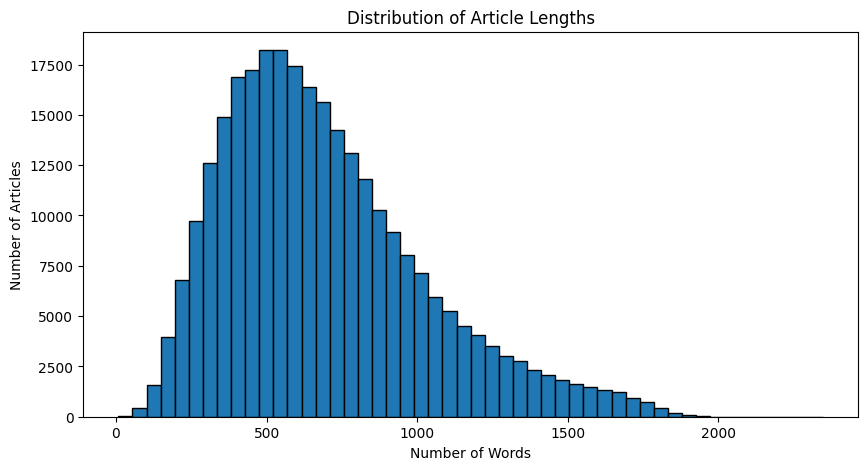

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(article_lengths, bins=50, edgecolor="black")
plt.title("Distribution of Article Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.show()

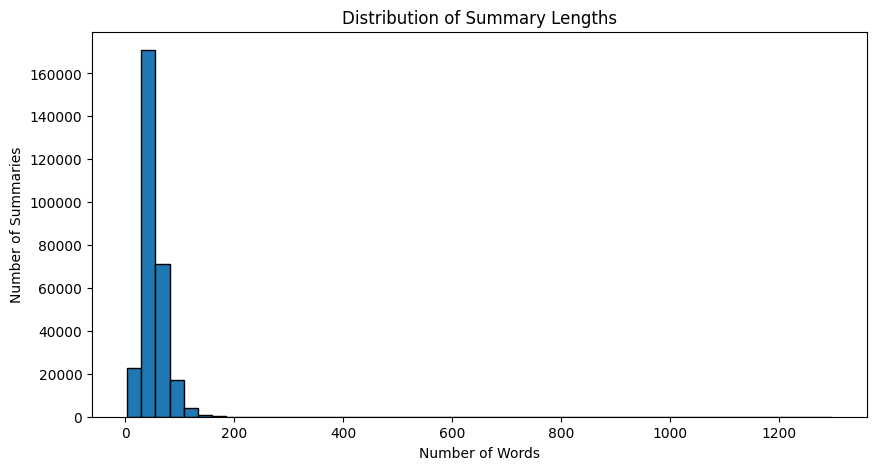

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(highligh_lengths, bins=50, edgecolor="black")
plt.title("Distribution of Summary Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Summaries")
plt.show()

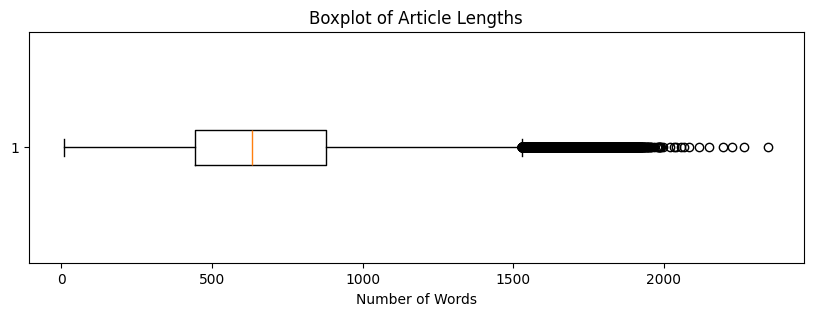

In [ ]:


plt.figure(figsize=(10,3))
plt.boxplot(article_lengths, vert=False)
plt.title("Boxplot of Article Lengths")
plt.xlabel("Number of Words")
plt.show()

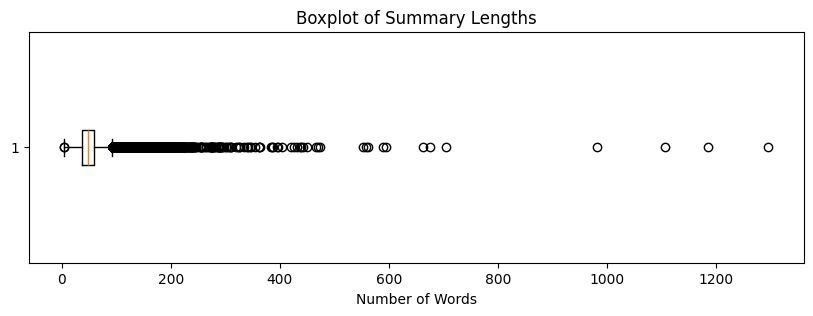

In [ ]:
plt.figure(figsize=(10,3))
plt.boxplot(highligh_lengths, vert=False)
plt.title("Boxplot of Summary Lengths")
plt.xlabel("Number of Words")
plt.show()

In [ ]:
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get("hugging_face"))

In [ ]:
!pip install unsloth


  Using cached peft-0.19.1-py3-none-any.whl.metadata (15 kB)
  Using cached huggingface_hub-1.23.0-py3-none-any.whl.metadata (14 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
Using cached peft-0.19.1-py3-none-any.whl (680 kB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.33.5
    Uninstalling huggingface-hub-0.33.5:
      Successfully uninstalled huggingface-hub-0.33.5
  Attempting uninstall: peft
    Found existing installation: peft 0.16.0
    Uninstalling peft-0.16.0:
      Successfully uninstalled peft-0.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import torch

from unsloth import FastLanguageModel

from transformers import TrainingArguments

from peft import LoraConfig
from trl import SFTTrainer, SFTConfig

/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:1427: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


NotImplementedError: Unsloth cannot find any torch accelerator? You need a GPU.

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

False


RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [ ]:
max_seq_length = 1024

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="meta-llama/Llama-3.2-1B-Instruct",
    max_seq_length=max_seq_length,
    dtype=None,
    load_in_4bit=True,
)

In [ ]:
print(tokenizer.chat_template)


In [ ]:
def format_template(sample):
  messages = [
      {
            "role": "system",
            "content": "You are a helpful assistant that summarizes news articles."
      },
      {
            "role": "user",
            "content": f"Summarize the following news article:\n\n{sample['article']}"
      },
      {
            "role": "assistant",
            "content": sample["highlights"]
      }
  ]

  return {"messages":messages}


transformed_data = removed_dataset.map(format_template)



In [ ]:
print(transformed_data["train"][0]["messages"])

In [ ]:
def apply_to_all(sample):
  text = tokenizer.apply_chat_template(
      sample["messages"],
      tokenize=False,
      add_generation_prompt=False
  )


  return {"text":text}

formatted_data = transformed_data.map(apply_to_all)

In [ ]:
print(formatted_data["test"][0]["text"])

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

In [ ]:
train_dataset = (
    formatted_data["train"]
    .shuffle(seed=42)
    .select(range(20000))
)

validation_dataset = (
    formatted_data["validation"]
    .shuffle(seed=42)
    .select(range(1000))
)

test_dataset = (
    formatted_data["test"]
    .shuffle(seed=42)
    .select(range(1000))
)



trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    args=SFTConfig(
        dataset_text_field="text",
        max_length=1024,
        packing=False,

        output_dir="llama3_summarizer",

        num_train_epochs=1,

        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,

        learning_rate=2e-4,
        warmup_ratio=0.03,
        weight_decay=0.01,

        optim="adamw_8bit",
        lr_scheduler_type="cosine",

        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),

        logging_strategy="steps",
        logging_steps=25,

        save_strategy="steps",
        save_steps=250,
        save_total_limit=3,

        eval_strategy="steps",
        eval_steps=250,

        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        report_to="none",
        seed=3407,
    ),
)

In [ ]:
train_result = trainer.train(
    resume_from_checkpoint=True)

model.save_pretrained("llama3_summarizer_lora")
tokenizer.save_pretrained("llama3_summarizer_lora")

trainer.save_state()

import json

with open("llama3_summarizer_lora/training_metrics.json", "w") as f:
    json.dump(train_result.metrics, f, indent=4)